# Analisa Data Menggunakan Regresi LInier




## 1. Konsep Dasar Regresi Linier

$$
\hat{\beta} = (X^T X)^{-1}X^T Y
$$

Regresi linier sederhana digunakan untuk melihat hubungan antara satu variabel bebas dan satu variabel terikat. Bentuk umum model regresi linier sederhana adalah:

$$
\hat{Y} = p_0 + p_1X
$$

Keterangan:

- \(\hat{Y}\) = nilai **Y prediksi** atau nilai Sales yang diperkirakan oleh model.
- \(Y\) = nilai **Y asli** atau Sales sebenarnya dari data.
- \(X\) = variabel bebas/predictor. Pada laporan ini, \(X\) dianggap sebagai **TV**.
- \(p_0\) = \(\beta_0\), yaitu **intercept/konstanta**. Nilai ini menunjukkan prediksi \(Y\) ketika \(X = 0\).
- \(p_1\) = \(\beta_1\), yaitu **koefisien regresi/slope**. Nilai ini menunjukkan perubahan rata-rata \(Y\) setiap \(X\) naik 1 satuan.

Jadi, tujuan regresi linier adalah mencari nilai \(p_0\) dan \(p_1\) terbaik agar garis regresi paling dekat dengan titik-titik data.



## 2. Data yang Digunakan

Data terdiri dari 7 titik, yaitu A sampai G. Data ini mengikuti titik yang dibuat pada GeoGebra.


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display

data = pd.DataFrame({
    "Titik": ["A", "B", "C", "D", "E", "F", "G"],
    "TV_X": [2, 4, 3, 3, 3, 4, 5],
    "Sales_Y": [2, 3, 5, 4, 3, 5, 6]
})

display(data)


,Titik,TV_X,Sales_Y
0,A,2,2
1,B,4,3
2,C,3,5
3,D,3,4
4,E,3,3
5,F,4,5
6,G,5,6



Berdasarkan data di atas:

- \(X\) adalah nilai pada kolom **TV_X**.
- \(Y\) adalah nilai pada kolom **Sales_Y**.
- Jumlah data adalah 7, sehingga \(n = 7\).



## 3. Perhitungan Analitik Menggunakan Matrix

Bagian ini mengikuti perhitungan pada file Excel yang diberikan. Rumus yang digunakan adalah:

$$
\hat{\beta} = (X^TX)^{-1}X^TY
$$

Dalam regresi linier sederhana, matrix \(X\) tidak hanya berisi nilai variabel TV, tetapi juga ditambah kolom angka 1. Kolom angka 1 digunakan untuk menghitung \(p_0\) atau intercept.

Matrix \(X\) dibuat sebagai berikut:

$$
X =
\begin{bmatrix}
1 & 2 \\
1 & 4 \\
1 & 3 \\
1 & 3 \\
1 & 3 \\
1 & 4 \\
1 & 5
\end{bmatrix}
$$

Kolom pertama berisi angka 1 untuk intercept, sedangkan kolom kedua berisi nilai X/TV.



## 3.1 Menghitung \(X^T\)

Transpose berarti mengubah baris menjadi kolom dan kolom menjadi baris. Dari matrix \(X\), diperoleh:

$$
X^T =
\begin{bmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
2 & 4 & 3 & 3 & 3 & 4 & 5
\end{bmatrix}
$$



## 3.2 Menghitung \(X^TX\)

Perhitungan pada Excel menghasilkan:

$$
X^TX =
\begin{bmatrix}
7 & 24 \\
24 & 88
\end{bmatrix}
$$

Penjelasannya:

$$
7 = 1+1+1+1+1+1+1
$$

$$
24 = 2+4+3+3+3+4+5
$$

$$
88 = 2^2+4^2+3^2+3^2+3^2+4^2+5^2
$$

$$
88 = 4+16+9+9+9+16+25
$$



## 3.3 Menghitung Determinan \(X^TX\)

Karena \(X^TX\) adalah matrix 2x2, determinannya dihitung dengan rumus:

$$
det =
(ad) - (bc)
$$

Untuk matrix:

$$
\begin{bmatrix}
7 & 24 \\
24 & 88
\end{bmatrix}
$$

maka:

$$
det = (7 \times 88) - (24 \times 24)
$$

$$
det = 616 - 576 = 40
$$

Karena determinannya tidak sama dengan nol, matrix \(X^TX\) dapat diinvers.



## 3.4 Menghitung Invers \((X^TX)^{-1}\)

Untuk matrix 2x2:

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

inversnya adalah:

$$
\frac{1}{ad-bc}
\begin{bmatrix}
d & -b \\
-c & a
\end{bmatrix}
$$

Maka untuk:

$$
X^TX =
\begin{bmatrix}
7 & 24 \\
24 & 88
\end{bmatrix}
$$

diperoleh adjoin:

$$
\begin{bmatrix}
88 & -24 \\
-24 & 7
\end{bmatrix}
$$

Karena determinannya 40, maka:

$$
(X^TX)^{-1}
=
\frac{1}{40}
\begin{bmatrix}
88 & -24 \\
-24 & 7
\end{bmatrix}
$$

$$
(X^TX)^{-1}
=
\begin{bmatrix}
2.2 & -0.6 \\
-0.6 & 0.175
\end{bmatrix}
$$



## 3.5 Menghitung \(X^TY\)

Perhitungan \(X^TY\) menghasilkan:

$$
X^TY =
\begin{bmatrix}
28 \\
102
\end{bmatrix}
$$

Penjelasannya:

$$
28 = 2+3+5+4+3+5+6
$$

$$
102 = (2 \times 2)+(4 \times 3)+(3 \times 5)+(3 \times 4)+(3 \times 3)+(4 \times 5)+(5 \times 6)
$$

$$
102 = 4+12+15+12+9+20+30
$$



## 3.6 Menghitung Beta atau Koefisien Regresi

Rumus akhir:

$$
\hat{\beta} = (X^TX)^{-1}X^TY
$$

$$
\hat{\beta}
=
\begin{bmatrix}
2.2 & -0.6 \\
-0.6 & 0.175
\end{bmatrix}
\begin{bmatrix}
28 \\
102
\end{bmatrix}
$$

Untuk \(p_0\):

$$
p_0 = (2.2 \times 28) + (-0.6 \times 102)
$$

$$
p_0 = 61.6 - 61.2 = 0.4
$$

Untuk \(p_1\):

$$
p_1 = (-0.6 \times 28) + (0.175 \times 102)
$$

$$
p_1 = -16.8 + 17.85 = 1.05
$$

Jadi:

$$
\hat{\beta}
=
\begin{bmatrix}
0.4 \\
1.05
\end{bmatrix}
$$



## 4. Visualisasi dengan GeoGebra

Pada GeoGebra, data dimasukkan sebagai titik koordinat:

```text
A = (2, 2)
B = (4, 3)
C = (3, 5)
D = (3, 4)
E = (3, 3)
F = (4, 5)
G = (5, 6)
```

Kemudian dibuat garis regresi sehingga diperoleh persamaan:

$$
f: y = 1.05x + 0.4
$$

Persamaan ini sama dengan hasil perhitungan Python dan matrix:

$$
\hat{Y} = 0.4 + 1.05X
$$

Titik \(I = (2, 2.5)\) pada GeoGebra adalah contoh titik prediksi saat \(X = 2\).

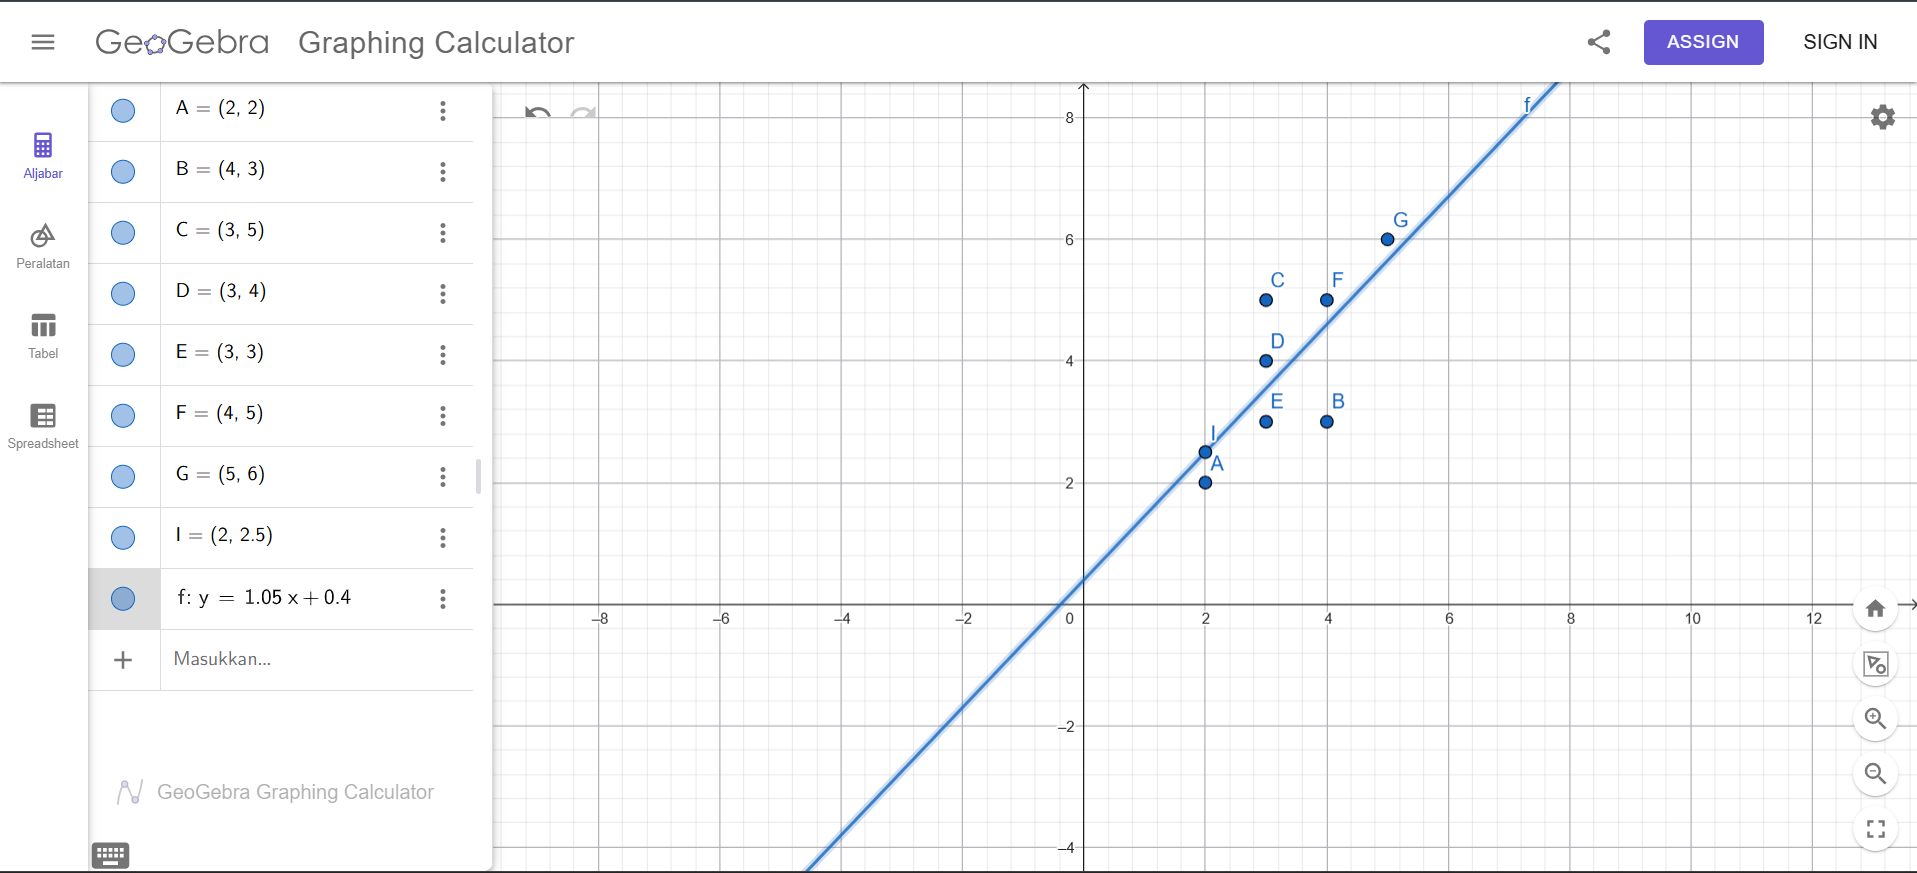